# TPV Route Planning

Route optimisation for airborne meteorological surveys of Tropopause Polar Vortex (TPV) systems.

**Mission:** BASE → transit → observe TPV interior (parallel chords ⊥ major axis) → satellite coincidence segment → return to BASE

**Dependencies:** `numpy` `matplotlib` `shapely` `geopandas`

---

## Module structure

| Module | Cells | Content |
|--------|-------|---------|
| **1** | this file | Geometry utilities · PCA ellipse fit · candidate chord generation |
| 2 | — | Obstacle avoidance (Restricted Airspace) · Visibility graph · ATC zone penalty |
| 3 | — | Satellite coincidence segment · departure-time scheduling |
| 4 | — | Full route optimisation · dropsonde zone scoring · output |

All tunable parameters are defined at the top of the **Parameters** cell.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import LineString, Polygon, Point
from itertools import combinations
from math import cos, sin, sqrt, pi, radians, degrees, atan2
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════════════════
# TUNABLE PARAMETERS  —  edit here only
# ════════════════════════════════════════════════════════════════════════════

AIRCRAFT_SPEED_KMH  = 850.0   # G3 cruise speed (km/h)
FLIGHT_TIME_H       = 5.0     # total mission time budget, including transit (hours)
TOTAL_BUDGET_KM     = AIRCRAFT_SPEED_KMH * FLIGHT_TIME_H   # 4 250 km

ATC_PENALTY_FACTOR  = 1.35    # effective-distance multiplier inside ATC zones (range 1.25–1.5)
TURN_PENALTY_MIN    = 7.5     # time penalty per heading change (minutes, range 5–10)
TURN_PENALTY_KM     = TURN_PENALTY_MIN / 60.0 * AIRCRAFT_SPEED_KMH   # ≈ 106 km

MIN_LEG_SPACING_KM  = 50.0   # minimum spacing between parallel observation legs  [TBD — confirm with scientist]
MAX_ANGLE_DEV_DEG   = 5.0    # max allowed chord-direction deviation from ideal (degrees)
N_ANGLE_SAMPLES     = 3      # number of angle-deviation samples within ±MAX_ANGLE_DEV_DEG

T_MIN_SAT_MIN       = 10.0   # minimum satellite coincidence time (minutes)

# ════════════════════════════════════════════════════════════════════════════
print(f'Total budget      : {TOTAL_BUDGET_KM:.0f} km')
print(f'Turn penalty      : {TURN_PENALTY_KM:.0f} km / turn')
print(f'Min leg spacing   : {MIN_LEG_SPACING_KM:.0f} km')
print(f'Angle deviation   : ±{MAX_ANGLE_DEV_DEG:.0f}° ({N_ANGLE_SAMPLES} samples)')

Total budget      : 4250 km
Turn penalty      : 106 km / turn
Min leg spacing   : 50 km
Angle deviation   : ±5° (3 samples)


## Module 1 — Geometry utilities

All geometric operations use **shapely** so the code runs with a standard `pip install` and is independent of ArcGIS.

| Function | Purpose |
|----------|---------|
| `fit_pca_ellipse` | Fit a 2-D ellipse to polygon vertices via PCA; returns center, semi-axes a ≥ b, orientation φ |
| `chord_in_polygon` | Intersect an infinite line with a shapely Polygon; return the two boundary crossing points and chord length |
| `generate_candidate_chords` | Enumerate all candidate observation chords (direction ≈ minor axis, evenly spaced along major axis) |
| `straight_dist` | Straight-line distance between two points — obstacle avoidance is added in Module 2 |

In [2]:
def rot2d(angle_rad):
    c, s = cos(angle_rad), sin(angle_rad)
    return np.array([[c, -s], [s, c]])


def fit_pca_ellipse(pts):
    """PCA ellipse fit.
    Returns (center, a, b, phi): centroid (km), major semi-axis a (km),
    minor semi-axis b (km), major-axis orientation phi (radians).
    """
    pts = np.asarray(pts, float)
    center = pts.mean(axis=0)
    cov = np.cov((pts - center).T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
    a   = 2.0 * sqrt(max(eigvals[0], 0.))
    b   = 2.0 * sqrt(max(eigvals[1], 0.))
    phi = atan2(eigvecs[1, 0], eigvecs[0, 0])
    return center, a, b, phi


def chord_in_polygon(offset_pt, direction, poly, far=2e4):
    """Chord of the line through offset_pt in direction inside shapely Polygon poly.

    Returns (pt_a, pt_b, length_km) where pt_a is the entry when flying in +direction,
    or None if the line does not cross the polygon.
    """
    p = np.asarray(offset_pt, float)
    d = np.asarray(direction,  float)
    d = d / np.linalg.norm(d)

    line    = LineString([p - far * d, p + far * d])
    segment = poly.intersection(line)

    if segment.is_empty:
        return None
    if segment.geom_type == 'MultiLineString':
        segment = max(segment.geoms, key=lambda g: g.length)
    if segment.geom_type != 'LineString' or segment.length < 0.5:
        return None

    coords = np.array(segment.coords)
    pt_a, pt_b = coords[0], coords[-1]
    if np.dot(pt_a - p, d) > np.dot(pt_b - p, d):
        pt_a, pt_b = pt_b, pt_a
    return pt_a, pt_b, float(segment.length)


def generate_candidate_chords(tpv_poly, center, a, phi,
                               min_spacing=MIN_LEG_SPACING_KM,
                               angle_devs_deg=None):
    """Enumerate candidate observation chords through tpv_poly (shapely Polygon).

    Direction: minor axis (phi + 90°) ± each value in angle_devs_deg.
    Positions: evenly spaced along major axis at intervals of min_spacing km.

    Returns list of dicts: {pt_a, pt_b, length, offset, angle_dev, direction}.
    Entry/exit are assigned by build_route during optimisation.
    """
    if angle_devs_deg is None:
        angle_devs_deg = [0]

    major   = np.array([cos(phi), sin(phi)])
    n_steps = max(1, int(2.0 * a / min_spacing)) + 1
    offsets = np.linspace(-a * 0.95, a * 0.95, n_steps)

    chords = []
    for dev in angle_devs_deg:
        chord_angle = phi + pi / 2 + radians(dev)
        direction   = np.array([cos(chord_angle), sin(chord_angle)])
        for d in offsets:
            pt = np.asarray(center) + d * major
            result = chord_in_polygon(pt, direction, tpv_poly)
            if result is None:
                continue
            pt_a, pt_b, length = result
            chords.append(dict(
                pt_a=pt_a, pt_b=pt_b, length=length,
                offset=float(d), angle_dev=dev, direction=direction.copy()
            ))
    return chords


def build_route(base, ordered_chords):
    """Construct the complete flight route: BASE → chord_1 → ... → chord_n → BASE.

    Turn penalty (TURN_PENALTY_KM) is charged TWICE per chord:
      - entry: turning from the transit heading to the chord direction
      - exit:  turning from the chord direction to the next transit heading
    Total turns = 2 × n_chords.

    All transit segments and turn penalties are included in total_dist.
    Returns dict: {waypoints, seg_types, total_dist, tpv_dist, n_turns, feasible, budget_remaining}.
    """
    pos  = np.asarray(base, float)
    wpts = [pos.copy()]
    segs = []
    total_dist = tpv_dist = 0.0
    n_turns = 0

    for c in ordered_chords:
        pt_a = np.asarray(c['pt_a'], float)
        pt_b = np.asarray(c['pt_b'], float)

        # Choose entry: whichever endpoint is closer to current position
        if np.linalg.norm(pt_a - pos) <= np.linalg.norm(pt_b - pos):
            entry, exit_ = pt_a, pt_b
        else:
            entry, exit_ = pt_b, pt_a

        # Transit segment to chord entry
        total_dist += float(np.linalg.norm(entry - pos))
        wpts.append(entry)
        segs.append('transit')

        # Turn 1: transit heading → chord direction
        total_dist += TURN_PENALTY_KM
        n_turns += 1

        # Fly the chord inside the TPV polygon
        total_dist += c['length']
        tpv_dist   += c['length']
        wpts.append(exit_)
        segs.append('tpv')

        # Turn 2: chord direction → next transit heading (or return to BASE)
        total_dist += TURN_PENALTY_KM
        n_turns += 1

        pos = exit_

    # Return transit to BASE
    total_dist += float(np.linalg.norm(np.asarray(base) - pos))
    wpts.append(np.asarray(base, float))
    segs.append('transit')

    return dict(
        waypoints=np.array(wpts),
        seg_types=segs,
        total_dist=total_dist,
        tpv_dist=tpv_dist,
        n_turns=n_turns,
        feasible=total_dist <= TOTAL_BUDGET_KM,
        budget_remaining=TOTAL_BUDGET_KM - total_dist,
    )


def best_multi_chord_route(base, chords, n_chords,
                            min_spacing=MIN_LEG_SPACING_KM):
    """Find the combination of n_chords that maximises TPV distance within budget.

    Tries both ascending and descending offset orders for each combination.
    Enforces min_spacing between adjacent chord offsets.
    Returns the best route dict, or None if no feasible combination exists.
    """
    best = None
    best_tpv = -1.0

    for combo in combinations(chords, n_chords):
        offsets = sorted(c['offset'] for c in combo)
        if n_chords > 1 and any(
            offsets[i+1] - offsets[i] < min_spacing
            for i in range(n_chords - 1)
        ):
            continue
        for ordered in [
            sorted(combo, key=lambda c:  c['offset']),
            sorted(combo, key=lambda c: -c['offset']),
        ]:
            route = build_route(base, ordered)
            if route['feasible'] and route['tpv_dist'] > best_tpv:
                best_tpv = route['tpv_dist']
                best = route

    return best


def straight_dist(p, q):
    """Straight-line distance (km). Obstacle avoidance is added in Module 2."""
    return float(np.linalg.norm(np.asarray(q, float) - np.asarray(p, float)))


print('Utilities loaded.')

Utilities loaded.


## Synthetic test data

A noisy closed polygon (100 vertices) stands in for a real TPV contour.
True semi-axes: a = 200 km, b = 120 km, orientation = 30°.  
BASE is placed ~979 km from the centroid (GOOSE BAY scale).

**To use real data:** replace `TPV_PTS` with vertices loaded from a shapefile via geopandas, and set `BASE` to the actual base coordinates in the same local km frame.

In [3]:
np.random.seed(42)
A_TRUE   = 200.            # km, true major semi-axis
B_TRUE   = 120.            # km, true minor semi-axis
PHI_TRUE = radians(30.)    # true orientation

th     = np.linspace(0, 2*pi, 101)[:-1]          # 100 vertices
R_true = rot2d(PHI_TRUE)
noise  = np.random.randn(100, 2) * 10.            # ±10 km boundary irregularity
TPV_PTS = (R_true @ np.vstack([A_TRUE*np.cos(th),
                                B_TRUE*np.sin(th)])).T + noise

# shapely Polygon — .buffer(0) fixes any self-intersections from noise
tpv_poly = Polygon(TPV_PTS).buffer(0)

BASE = np.array([-700., 600.])   # km from TPV centroid  (replace with real coords)

d_transit_one_way = straight_dist(BASE, TPV_PTS.mean(axis=0))
d_transit_rt      = 2.0 * d_transit_one_way

print(f'TPV polygon         : {len(TPV_PTS)} vertices')
print(f'Extent              : {TPV_PTS[:,0].ptp():.0f} × {TPV_PTS[:,1].ptp():.0f} km')
print(f'BASE → centroid     : {d_transit_one_way:.0f} km')
print(f'Round-trip transit  : {d_transit_rt:.0f} km  of {TOTAL_BUDGET_KM:.0f} km budget')
print(f'Budget after transit: {TOTAL_BUDGET_KM - d_transit_rt:.0f} km  available for observation')

TPV polygon         : 100 vertices
Extent              : 377 × 319 km
BASE → centroid     : 921 km
Round-trip transit  : 1842 km  of 4250 km budget
Budget after transit: 2408 km  available for observation


## PCA ellipse fit

The PCA ellipse gives:
- **φ** (major axis orientation) → the direction chords should be perpendicular to
- **a, b** (semi-axes) → the range of valid chord offsets along the major axis

The minor axis direction **φ + 90°** is the ideal chord direction.

PCA fit :  a = 284.2 km   b = 169.9 km   φ = -150.5°
True    :  a = 200.0 km   b = 120.0 km   φ = 30.0°
Ideal chord direction (minor axis): (0.492, -0.871)


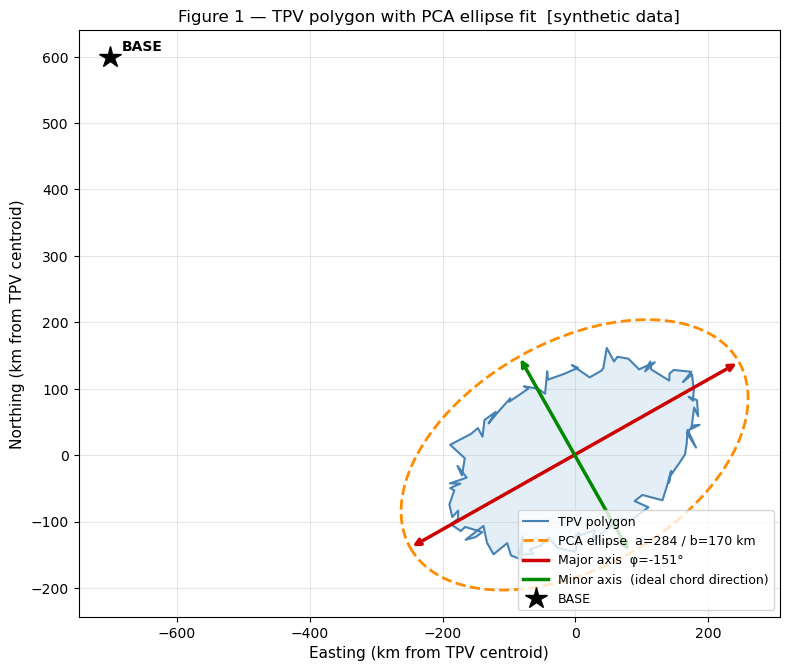

In [4]:
center, a_fit, b_fit, phi_fit = fit_pca_ellipse(TPV_PTS)

print(f'PCA fit :  a = {a_fit:.1f} km   b = {b_fit:.1f} km   φ = {degrees(phi_fit):.1f}°')
print(f'True    :  a = {A_TRUE:.1f} km   b = {B_TRUE:.1f} km   φ = {degrees(PHI_TRUE):.1f}°')

major_dir = np.array([cos(phi_fit),          sin(phi_fit)])
minor_dir = np.array([cos(phi_fit + pi/2),   sin(phi_fit + pi/2)])
print(f'Ideal chord direction (minor axis): '
      f'({minor_dir[0]:.3f}, {minor_dir[1]:.3f})')

# Ellipse outline for plotting
R_fit  = rot2d(phi_fit)
th_e   = np.linspace(0, 2*pi, 300)
ell_xy = (R_fit @ np.vstack([a_fit*np.cos(th_e),
                              b_fit*np.sin(th_e)])).T + center

# ── Figure 1: TPV polygon + PCA ellipse ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))

closed = np.vstack([TPV_PTS, TPV_PTS[0]])
ax.fill(TPV_PTS[:,0], TPV_PTS[:,1], color='#cfe0f0', alpha=0.55, zorder=1)
ax.plot(closed[:,0],  closed[:,1],  color='steelblue', lw=1.5,
        zorder=2, label='TPV polygon')
ax.plot(ell_xy[:,0],  ell_xy[:,1],  '--', color='darkorange', lw=2,
        zorder=3, label=f'PCA ellipse  a={a_fit:.0f} / b={b_fit:.0f} km')

for vec, col, lbl in [
    (major_dir * a_fit, '#cc0000', f'Major axis  φ={degrees(phi_fit):.0f}°'),
    (minor_dir * b_fit, '#008800', 'Minor axis  (ideal chord direction)'),
]:
    ax.annotate('', xy=center+vec, xytext=center-vec,
                arrowprops=dict(arrowstyle='<->', color=col, lw=2.5))
    ax.plot([], [], color=col, lw=2.5, label=lbl)

ax.plot(*BASE, '*', color='black', ms=16, zorder=7, label='BASE')
ax.annotate('BASE', BASE, textcoords='offset points',
            xytext=(8, 4), fontsize=10, fontweight='bold')

ax.set_aspect('equal')
ax.set_xlabel('Easting (km from TPV centroid)', fontsize=11)
ax.set_ylabel('Northing (km from TPV centroid)', fontsize=11)
ax.set_title('Figure 1 — TPV polygon with PCA ellipse fit  [synthetic data]',
             fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Candidate chord generation and budget feasibility

Chords are generated for `N_ANGLE_SAMPLES` directions spanning ±`MAX_ANGLE_DEV_DEG` around the ideal minor-axis direction.
Along the major axis, positions are spaced `MIN_LEG_SPACING_KM` apart.

**Budget feasibility** (straight-line, no obstacles yet):
```
single_trip = dist(BASE → pt_a) + chord length + dist(pt_b → BASE)
remaining   = TOTAL_BUDGET_KM − single_trip
```
A positive `remaining` means there is budget left for a second transect or satellite coincidence.

In [5]:
angle_devs = np.linspace(-MAX_ANGLE_DEV_DEG, MAX_ANGLE_DEV_DEG,
                          N_ANGLE_SAMPLES).tolist()

chords = generate_candidate_chords(
    tpv_poly, center, a_fit, phi_fit,
    min_spacing=MIN_LEG_SPACING_KM,
    angle_devs_deg=angle_devs
)

print(f'Candidate chords: {len(chords)}  '
      f'(angle devs {angle_devs[0]:+.0f}° to {angle_devs[-1]:+.0f}°, '
      f'spacing {MIN_LEG_SPACING_KM:.0f} km)')
print()

# Find best routes for 1, 2, 3 chords
routes = {}
for n in [1, 2, 3]:
    r = best_multi_chord_route(BASE, chords, n)
    routes[n] = r
    if r:
        print(f'{n}-chord route:  TPV dist = {r["tpv_dist"]:.0f} km   '
              f'total dist = {r["total_dist"]:.0f} km   '
              f'turns = {r["n_turns"]}   '
              f'remaining = {r["budget_remaining"]:.0f} km')
    else:
        print(f'{n}-chord route:  no feasible combination found')

Candidate chords: 24  (angle devs -5° to +5°, spacing 50 km)

1-chord route:  TPV dist = 244 km   total dist = 2325 km   turns = 2   remaining = 1925 km
2-chord route:  TPV dist = 480 km   total dist = 2616 km   turns = 4   remaining = 1634 km
3-chord route:  TPV dist = 682 km   total dist = 3342 km   turns = 6   remaining = 908 km


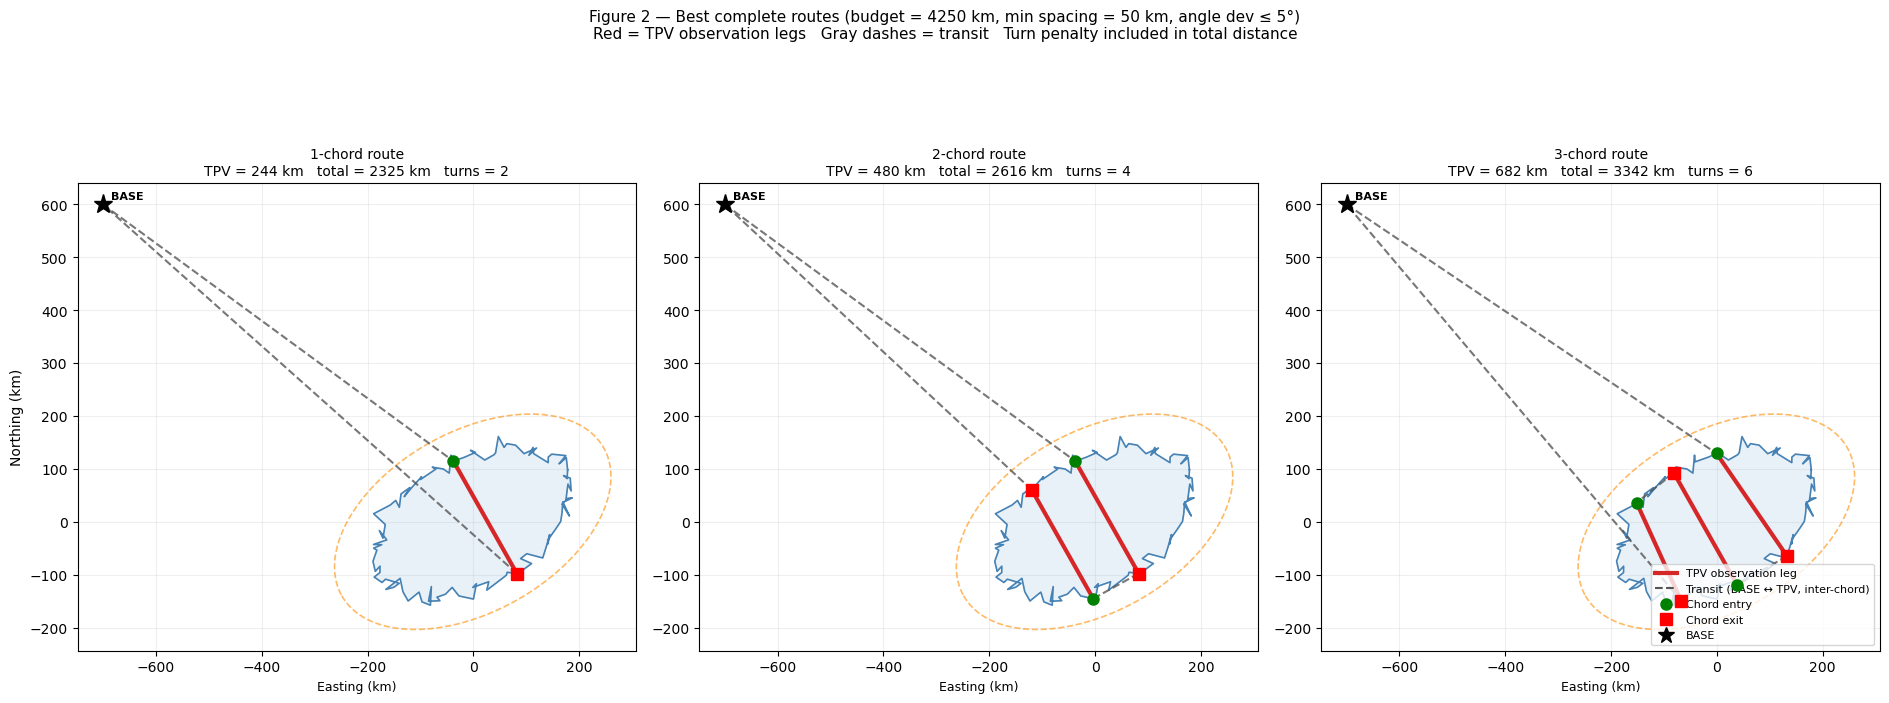

In [6]:
# ── Figure 2: Complete routes for 1, 2, 3 chords ─────────────────────────
def plot_route(ax, route, tpv_pts, ell_xy, base, title):
    """Draw a complete route on ax: transit (dashed gray) + TPV legs (solid blue)."""
    closed = np.vstack([tpv_pts, tpv_pts[0]])
    ax.fill(tpv_pts[:,0], tpv_pts[:,1], color='#cfe0f0', alpha=0.45, zorder=1)
    ax.plot(closed[:,0], closed[:,1], color='steelblue', lw=1.2, zorder=2)
    ax.plot(ell_xy[:,0], ell_xy[:,1], '--', color='darkorange',
            lw=1.2, alpha=0.6, zorder=3)

    if route is None:
        ax.set_title(title + '\n(no feasible route)', fontsize=10)
        return

    wpts = route['waypoints']
    segs = route['seg_types']

    for i, seg_type in enumerate(segs):
        p1, p2 = wpts[i], wpts[i+1]
        if seg_type == 'tpv':
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                    '-', color='#d62728', lw=3, zorder=5, solid_capstyle='round')
        else:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                    '--', color='#555555', lw=1.5, zorder=4, alpha=0.8)

    # Waypoint markers: entry (circle) and exit (square) for each chord
    tpv_idx = [i for i, s in enumerate(segs) if s == 'tpv']
    for idx in tpv_idx:
        ax.plot(*wpts[idx],   'o', color='green', ms=8, zorder=6)
        ax.plot(*wpts[idx+1], 's', color='red',   ms=8, zorder=6)

    # BASE marker
    ax.plot(*base, '*', color='black', ms=14, zorder=7)
    ax.annotate('BASE', base, textcoords='offset points',
                xytext=(6, 4), fontsize=8, fontweight='bold')

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.set_title(
        f'{title}\n'
        f'TPV = {route["tpv_dist"]:.0f} km   '
        f'total = {route["total_dist"]:.0f} km   '
        f'turns = {route["n_turns"]}',
        fontsize=10)


fig, axes = plt.subplots(1, 3, figsize=(19, 8))

for ax, n in zip(axes, [1, 2, 3]):
    plot_route(ax, routes[n], TPV_PTS, ell_xy, BASE, f'{n}-chord route')
    ax.set_xlabel('Easting (km)', fontsize=9)

axes[0].set_ylabel('Northing (km)', fontsize=10)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#d62728', lw=3,  label='TPV observation leg'),
    Line2D([0], [0], color='#555555', lw=1.5, ls='--', label='Transit (BASE ↔ TPV, inter-chord)'),
    Line2D([0], [0], marker='o', color='green', ms=8, ls='none', label='Chord entry'),
    Line2D([0], [0], marker='s', color='red',   ms=8, ls='none', label='Chord exit'),
    Line2D([0], [0], marker='*', color='black', ms=12, ls='none', label='BASE'),
]
axes[2].legend(handles=legend_elements, fontsize=8, loc='lower right')

fig.suptitle(
    f'Figure 2 — Best complete routes (budget = {TOTAL_BUDGET_KM:.0f} km, '
    f'min spacing = {MIN_LEG_SPACING_KM:.0f} km, '
    f'angle dev ≤ {MAX_ANGLE_DEV_DEG:.0f}°)\n'
    'Red = TPV observation legs   Gray dashes = transit   '
    'Turn penalty included in total distance',
    fontsize=11)
plt.tight_layout()
plt.show()